# Regularisation & Logistic Regression

This notebook covers two essential topics:

**Part A — Regularisation**  
**Scenario:** You are building a house price model with 50+ engineered features. The model performs perfectly on training data but terribly on new properties. You need to prevent overfitting.

**Part B — Logistic Regression**  
**Scenario:** Your bank wants to predict whether a loan applicant will default. The target is now binary (Default: Yes/No). Linear regression cannot handle this — you need Logistic Regression.

| Section | Topic |
|---|---|
| **Part A** | |
| 1 | The Overfitting Problem |
| 2 | Ridge Regression (L2) |
| 3 | Lasso Regression (L1) |
| 4 | ElasticNet |
| 5 | Choosing Alpha — Cross-Validated Tuning |
| **Part B** | |
| 6 | From Regression to Classification |
| 7 | The Sigmoid Function |
| 8 | Binary Cross-Entropy Loss |
| 9 | Logistic Regression with sklearn |
| 10 | Evaluation: Confusion Matrix, Precision, Recall, F1 |
| 11 | ROC Curve & AUC |
| 12 | Decision Threshold Tuning |
| 13 | Multiclass Logistic Regression |
| 14 | Summary |

---
## 0. Setup

In [44]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Linear models
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet, RidgeCV, LassoCV,
    LogisticRegression
)
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV
)
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, classification_report
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (11, 5)
np.random.seed(42)

print('Libraries loaded.')

Libraries loaded.


---
# PART A — REGULARISATION

---
## 1. The Overfitting Problem

We create a housing dataset with many features, including **irrelevant noise features**. Without regularisation, linear regression assigns non-zero weights to all features — including the noise.

> Adding more features always **reduces** training error. But it often **increases** test error. This is overfitting.

In [45]:
# Build a housing dataset with 5 real + 15 noise features
N = 300

# 5 real features
area      = np.random.normal(150, 40, N)      # m²
bedrooms  = np.random.randint(1, 6, N).astype(float)
age       = np.random.exponential(15, N).clip(0, 60)
quality   = np.random.randint(1, 6, N).astype(float)  # 1–5 rating
garage    = np.random.randint(0, 3, N).astype(float)

noise_eps = np.random.normal(0, 20_000, N)

price = (
    50_000
    + 2_500 * area
    + 15_000 * bedrooms
    + 20_000 * quality
    - 1_000  * age
    + 12_000 * garage
    + noise_eps
).round(-3)

# 15 pure noise features (no relationship with price)
noise_features = np.random.randn(N, 15)
noise_cols     = [f'noise_{i+1}' for i in range(15)]

df_house = pd.DataFrame(
    np.column_stack([area, bedrooms, age, quality, garage, noise_features]),
    columns=['area', 'bedrooms', 'age', 'quality', 'garage'] + noise_cols
)
df_house['price'] = price

print(f'Dataset: {df_house.shape[0]} houses x {df_house.shape[1]} columns')
print(f'  Real features:  5  (area, bedrooms, age, quality, garage)')
print(f'  Noise features: 15 (no true relationship with price)')
print(f'  Target:          price')

Dataset: 300 houses x 21 columns
  Real features:  5  (area, bedrooms, age, quality, garage)
  Noise features: 15 (no true relationship with price)
  Target:          price


In [46]:
all_features = [c for c in df_house.columns if c != 'price']
X = df_house[all_features].values
y = df_house['price'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

scaler  = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Baseline: plain linear regression on all 20 features
ols = LinearRegression()
ols.fit(X_train_s, y_train)

y_tr_ols = ols.predict(X_train_s)
y_te_ols = ols.predict(X_test_s)

train_rmse_ols = np.sqrt(mean_squared_error(y_train, y_tr_ols))
test_rmse_ols  = np.sqrt(mean_squared_error(y_test,  y_te_ols))
train_r2_ols   = r2_score(y_train, y_tr_ols)
test_r2_ols    = r2_score(y_test,  y_te_ols)

print('OLS (no regularisation) — 20 features (5 real + 15 noise):')
print(f'  Train RMSE: ${train_rmse_ols:>10,.0f}   Train R²: {train_r2_ols:.4f}')
print(f'  Test  RMSE: ${test_rmse_ols:>10,.0f}   Test  R²: {test_r2_ols:.4f}')
print()
gap = test_rmse_ols - train_rmse_ols
print(f'  Gap (test − train RMSE): ${gap:,.0f}  ← overfitting signal')

OLS (no regularisation) — 20 features (5 real + 15 noise):
  Train RMSE: $    20,945   Train R²: 0.9660
  Test  RMSE: $    23,568   Test  R²: 0.9342

  Gap (test − train RMSE): $2,623  ← overfitting signal


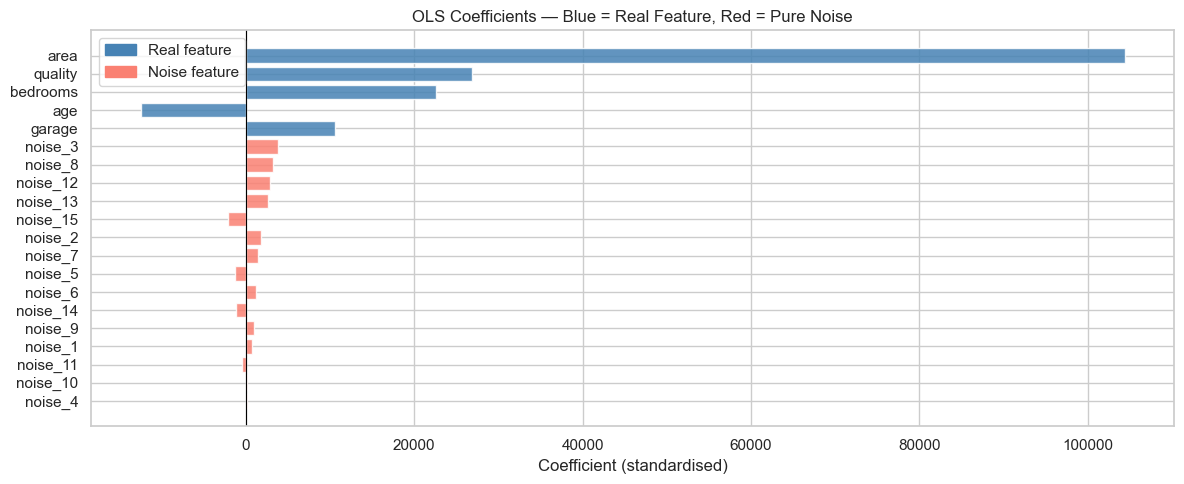

OLS assigns large coefficients to noise features.
The model is fitting to random patterns in the training data — this will not generalise.


In [47]:
# Show that OLS assigns large coefficients to noise features
feature_names = all_features

coeff_df = pd.DataFrame({
    'feature': feature_names,
    'coeff':   ols.coef_,
    'is_real': [True if f in ['area', 'bedrooms', 'age', 'quality', 'garage'] else False
                for f in feature_names]
}).sort_values('coeff', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
colours = ['steelblue' if r else 'salmon' for r in coeff_df['is_real']]
bars = ax.barh(coeff_df['feature'][::-1], coeff_df['coeff'][::-1], color=colours[::-1], alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Coefficient (standardised)')
ax.set_title('OLS Coefficients — Blue = Real Feature, Red = Pure Noise')

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='steelblue', label='Real feature'),
                   Patch(color='salmon',    label='Noise feature')])

plt.tight_layout()
plt.show()

print('OLS assigns large coefficients to noise features.')
print('The model is fitting to random patterns in the training data — this will not generalise.')

---
## 2. Ridge Regression (L2 Regularisation)

Ridge adds a **squared penalty** to the loss function:

$$J_{\text{Ridge}}(\mathbf{w}) = \underbrace{\frac{1}{m}\sum_{i=1}^{m}(\hat{y}_i - y_i)^2}_{\text{MSE}} + \underbrace{\alpha \sum_{j=1}^{p} w_j^2}_{\text{L2 penalty}}$$

- $\alpha$ (alpha) = **regularisation strength** — larger = more shrinkage
- The penalty **shrinks all coefficients toward zero** — but never exactly to zero
- This reduces variance (overfitting) at the cost of a little more bias

> **Geometric intuition:** OLS finds the minimum of the loss bowl. Ridge adds a constraint that the solution must lie inside a sphere of radius $1/\alpha$ centred at the origin. This forces coefficients to be small.

In [48]:
# Train Ridge for different alpha values
alphas = [0.001, 0.1, 1, 10, 100, 1000, 10000]

ridge_results = []
ridge_coeffs  = []

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_s, y_train)

    tr_rmse = np.sqrt(mean_squared_error(y_train, ridge.predict(X_train_s)))
    te_rmse = np.sqrt(mean_squared_error(y_test,  ridge.predict(X_test_s)))

    ridge_results.append({'alpha': a, 'train_rmse': tr_rmse, 'test_rmse': te_rmse})
    ridge_coeffs.append(ridge.coef_)

results_df = pd.DataFrame(ridge_results)

print(f"{'alpha':>8}   {'Train RMSE':>12}   {'Test RMSE':>12}   {'Train-Test Gap':>15}")
print('─' * 55)
for _, row in results_df.iterrows():
    gap = row['test_rmse'] - row['train_rmse']
    print(f"{row['alpha']:>8.3f}   ${row['train_rmse']:>10,.0f}   ${row['test_rmse']:>10,.0f}   ${gap:>14,.0f}")

print()
print('As alpha increases → gap shrinks → less overfitting.')
print('But too large alpha → test RMSE starts increasing again (underfitting).')

   alpha     Train RMSE      Test RMSE    Train-Test Gap
───────────────────────────────────────────────────────
   0.001   $    20,945   $    23,568   $         2,623
   0.100   $    20,945   $    23,566   $         2,621
   1.000   $    20,951   $    23,550   $         2,599
  10.000   $    21,506   $    23,756   $         2,250
 100.000   $    40,266   $    37,188   $        -3,078
1000.000   $    92,679   $    77,756   $       -14,923
10000.000   $   110,996   $    91,497   $       -19,498

As alpha increases → gap shrinks → less overfitting.
But too large alpha → test RMSE starts increasing again (underfitting).


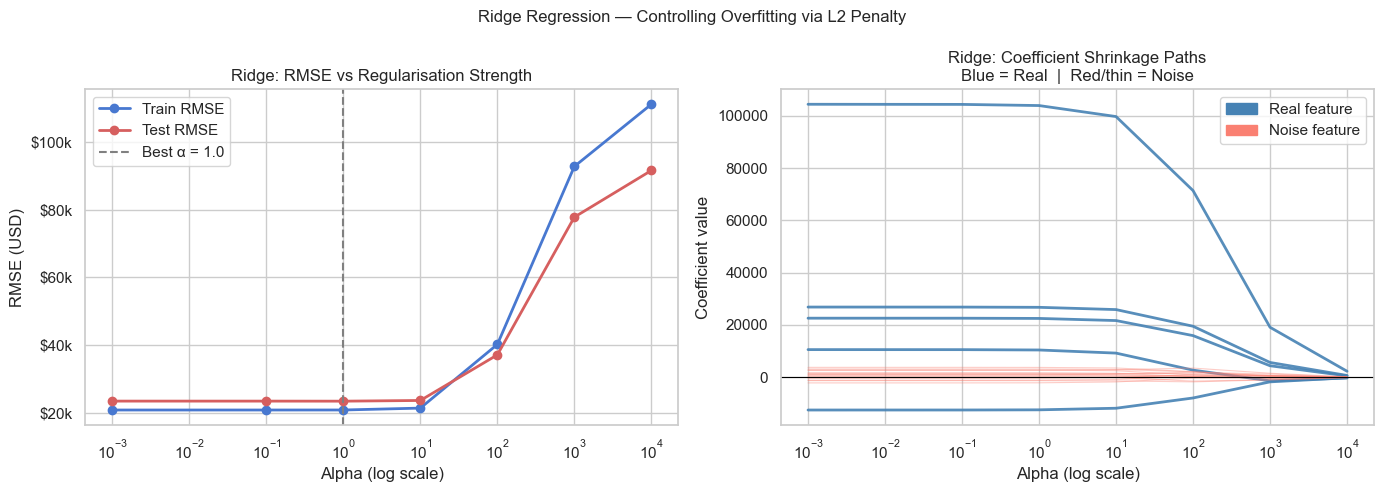

Ridge shrinks ALL coefficients — noise and real alike.
It reduces overfitting but does NOT perform feature selection (no coefficient = exactly 0).


In [49]:
# Visualise: coefficient shrinkage paths + RMSE vs alpha
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: RMSE vs alpha
axes[0].semilogx(results_df['alpha'], results_df['train_rmse'], 'b-o', lw=2, label='Train RMSE')
axes[0].semilogx(results_df['alpha'], results_df['test_rmse'],  'r-o', lw=2, label='Test RMSE')
best_alpha_idx = results_df['test_rmse'].idxmin()
best_alpha     = results_df.loc[best_alpha_idx, 'alpha']
axes[0].axvline(best_alpha, color='gray', ls='--', label=f'Best α = {best_alpha}')
axes[0].set_xlabel('Alpha (log scale)')
axes[0].set_ylabel('RMSE (USD)')
axes[0].set_title('Ridge: RMSE vs Regularisation Strength')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0].legend()

# Right: Coefficient shrinkage paths
coeffs_array = np.array(ridge_coeffs)  # shape (n_alphas, n_features)

for j, feat in enumerate(feature_names):
    is_real = feat in ['area', 'bedrooms', 'age', 'quality', 'garage']
    colour  = 'steelblue' if is_real else 'salmon'
    alpha_p = 0.9 if is_real else 0.4
    lw      = 2   if is_real else 0.8
    axes[1].semilogx(alphas, coeffs_array[:, j], color=colour, alpha=alpha_p, lw=lw)

axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_xlabel('Alpha (log scale)')
axes[1].set_ylabel('Coefficient value')
axes[1].set_title('Ridge: Coefficient Shrinkage Paths\nBlue = Real  |  Red/thin = Noise')
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color='steelblue', label='Real feature'),
                         Patch(color='salmon',    label='Noise feature')])

plt.suptitle('Ridge Regression — Controlling Overfitting via L2 Penalty', fontsize=12)
plt.tight_layout()
plt.show()

print('Ridge shrinks ALL coefficients — noise and real alike.')
print('It reduces overfitting but does NOT perform feature selection (no coefficient = exactly 0).')

---
## 3. Lasso Regression (L1 Regularisation)

Lasso uses an **absolute value penalty** instead of squared:

$$J_{\text{Lasso}}(\mathbf{w}) = \frac{1}{m}\sum_{i=1}^{m}(\hat{y}_i - y_i)^2 + \alpha \sum_{j=1}^{p} |w_j|$$

**Key difference from Ridge:**  
The L1 penalty has **corners** at the axes. The optimal solution often falls exactly at a corner — meaning some $w_j = 0$ exactly. This gives Lasso **automatic feature selection**.

| | Ridge (L2) | Lasso (L1) |
|---|---|---|
| Penalty term | $\sum w_j^2$ | $\sum |w_j|$ |
| Coefficients at 0? | No (only approaches 0) | Yes (exact zeros) |
| Feature selection? | No | **Yes** |
| Geometry | Sphere constraint | Diamond constraint |
| Best when | All features contribute a little | Many features are irrelevant |

In [50]:
# Lasso with the same alpha range
lasso_results = []
lasso_coeffs  = []
lasso_nonzero = []

lasso_alphas = [0.01, 0.1, 1, 10, 100, 500, 1000]

for a in lasso_alphas:
    lasso = Lasso(alpha=a, max_iter=10_000)
    lasso.fit(X_train_s, y_train)

    tr_rmse = np.sqrt(mean_squared_error(y_train, lasso.predict(X_train_s)))
    te_rmse = np.sqrt(mean_squared_error(y_test,  lasso.predict(X_test_s)))
    n_nonzero = np.sum(lasso.coef_ != 0)

    lasso_results.append({'alpha': a, 'train_rmse': tr_rmse,
                          'test_rmse': te_rmse, 'nonzero': n_nonzero})
    lasso_coeffs.append(lasso.coef_)

lasso_df = pd.DataFrame(lasso_results)

print(f"{'alpha':>8}   {'Train RMSE':>12}   {'Test RMSE':>12}   {'Non-zero coeff':>15}")
print('─' * 55)
for _, row in lasso_df.iterrows():
    print(f"{row['alpha']:>8.2f}   ${row['train_rmse']:>10,.0f}   ${row['test_rmse']:>10,.0f}   {row['nonzero']:>15.0f} / {len(feature_names)}")

print()
print('As alpha increases → more coefficients become exactly zero.')
print('Lasso performs automatic feature selection!')

   alpha     Train RMSE      Test RMSE    Non-zero coeff
───────────────────────────────────────────────────────
    0.01   $    20,945   $    23,568                20 / 20
    0.10   $    20,945   $    23,568                20 / 20
    1.00   $    20,945   $    23,566                20 / 20
   10.00   $    20,945   $    23,548                20 / 20
  100.00   $    20,951   $    23,378                20 / 20
  500.00   $    21,079   $    22,813                16 / 20
 1000.00   $    21,373   $    22,546                13 / 20

As alpha increases → more coefficients become exactly zero.
Lasso performs automatic feature selection!


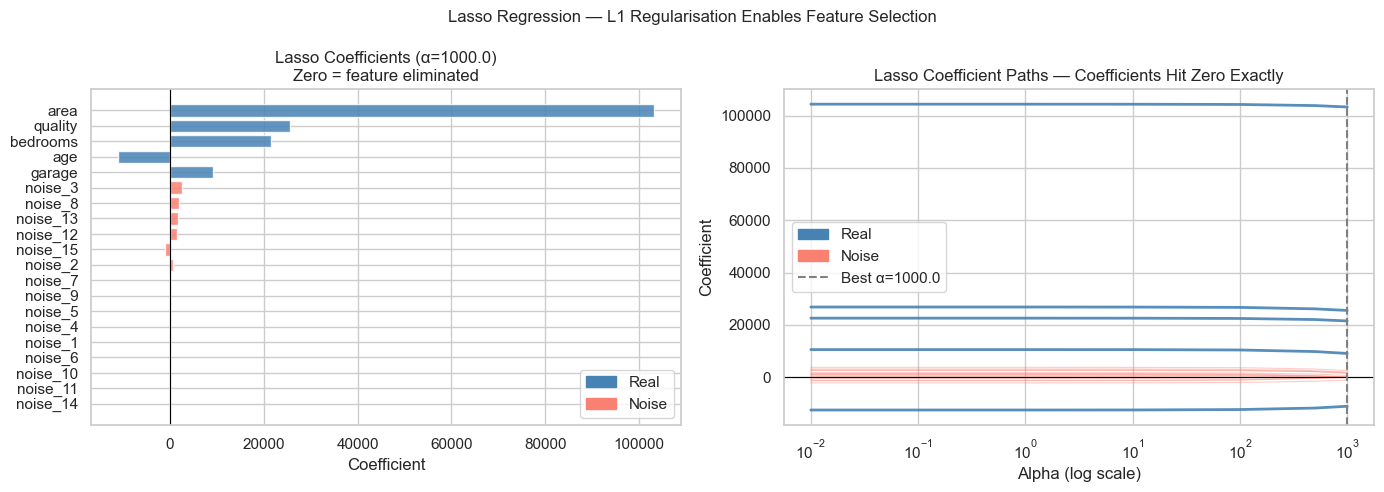

Features kept (non-zero):    ['area', 'quality', 'bedrooms', 'age', 'garage', 'noise_3', 'noise_8', 'noise_13', 'noise_12', 'noise_15', 'noise_2', 'noise_7', 'noise_9']
Features eliminated (=zero): ['noise_5', 'noise_4', 'noise_1', 'noise_6', 'noise_10', 'noise_11', 'noise_14']


In [51]:
# What does Lasso keep vs drop?
# Use alpha with best test RMSE
best_a = lasso_df.loc[lasso_df['test_rmse'].idxmin(), 'alpha']
lasso_best = Lasso(alpha=best_a, max_iter=10_000)
lasso_best.fit(X_train_s, y_train)

lasso_coeff_df = pd.DataFrame({
    'feature': feature_names,
    'coeff':   lasso_best.coef_,
    'is_real': [True if f in ['area', 'bedrooms', 'age', 'quality', 'garage']
                else False for f in feature_names]
}).sort_values('coeff', key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Coefficient bar chart (best alpha)
colours = ['steelblue' if r else 'salmon' for r in lasso_coeff_df['is_real']]
axes[0].barh(lasso_coeff_df['feature'][::-1], lasso_coeff_df['coeff'][::-1],
             color=colours[::-1], alpha=0.85)
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_xlabel('Coefficient')
axes[0].set_title(f'Lasso Coefficients (α={best_a})\nZero = feature eliminated')
axes[0].legend(handles=[Patch(color='steelblue', label='Real'),
                         Patch(color='salmon',    label='Noise')])

# Coefficient paths
coeffs_array_l = np.array(lasso_coeffs)
for j, feat in enumerate(feature_names):
    is_real = feat in ['area', 'bedrooms', 'age', 'quality', 'garage']
    colour  = 'steelblue' if is_real else 'salmon'
    alpha_p = 0.9 if is_real else 0.4
    lw      = 2   if is_real else 0.8
    axes[1].semilogx(lasso_alphas, coeffs_array_l[:, j], color=colour, alpha=alpha_p, lw=lw)

axes[1].axhline(0, color='black', lw=0.8)
axes[1].axvline(best_a, color='gray', ls='--', label=f'Best α = {best_a}')
axes[1].set_xlabel('Alpha (log scale)')
axes[1].set_ylabel('Coefficient')
axes[1].set_title('Lasso Coefficient Paths — Coefficients Hit Zero Exactly')
axes[1].legend(handles=[Patch(color='steelblue', label='Real'),
                          Patch(color='salmon', label='Noise'),
                          plt.Line2D([0], [0], color='gray', ls='--', label=f'Best α={best_a}')])

plt.suptitle('Lasso Regression — L1 Regularisation Enables Feature Selection', fontsize=12)
plt.tight_layout()
plt.show()

kept = lasso_coeff_df[lasso_coeff_df['coeff'] != 0]
dropped = lasso_coeff_df[lasso_coeff_df['coeff'] == 0]
print(f'Features kept (non-zero):    {kept["feature"].tolist()}')
print(f'Features eliminated (=zero): {dropped["feature"].tolist()}')

---
## 4. ElasticNet — Best of Both

ElasticNet combines L1 and L2 penalties:

$$J_{\text{EN}}(\mathbf{w}) = \frac{1}{m}\sum(\hat{y}_i - y_i)^2 + \alpha \left[ \rho \sum |w_j| + \frac{1-\rho}{2} \sum w_j^2 \right]$$

- $\alpha$ controls overall regularisation strength
- $\rho$ (`l1_ratio`) controls the mix: 0 = pure Ridge, 1 = pure Lasso

**When to use:** When you have correlated features. Lasso arbitrarily picks one from a correlated group. ElasticNet keeps both (Ridge-like behaviour for groups) while still eliminating truly irrelevant features (Lasso-like).

In [52]:
# Compare OLS, Ridge, Lasso, ElasticNet side by side
models = {
    'OLS':        LinearRegression(),
    'Ridge':      Ridge(alpha=best_alpha),
    'Lasso':      Lasso(alpha=best_a, max_iter=10_000),
    'ElasticNet': ElasticNet(alpha=best_a, l1_ratio=0.5, max_iter=10_000),
}

print(f"{'Model':>12}   {'Train RMSE':>12}   {'Test RMSE':>12}   {'Non-zero coeff':>15}")
print('─' * 58)

for name, model in models.items():
    model.fit(X_train_s, y_train)
    tr  = np.sqrt(mean_squared_error(y_train, model.predict(X_train_s)))
    te  = np.sqrt(mean_squared_error(y_test,  model.predict(X_test_s)))
    nz  = np.sum(model.coef_ != 0) if hasattr(model, 'coef_') else 'N/A'
    print(f"{name:>12}   ${tr:>10,.0f}   ${te:>10,.0f}   {nz:>15}")

print()
print('ElasticNet: middle ground — some feature elimination + correlated features handled well.')

       Model     Train RMSE      Test RMSE    Non-zero coeff
──────────────────────────────────────────────────────────
         OLS   $    20,945   $    23,568                20
       Ridge   $    20,951   $    23,550                20
       Lasso   $    21,373   $    22,546                13
  ElasticNet   $   113,338   $    93,233                19

ElasticNet: middle ground — some feature elimination + correlated features handled well.


---
## 5. Choosing Alpha — Cross-Validated Tuning

The regularisation strength $\alpha$ is a **hyperparameter** — not learned from data, set by you. You choose it via cross-validation.

In [53]:
# RidgeCV finds the best alpha using leave-one-out cross-validation
alphas_to_try = np.logspace(-2, 5, 50)   # 0.01 to 100,000

ridgecv = RidgeCV(alphas=alphas_to_try, cv=5, scoring='neg_root_mean_squared_error')
ridgecv.fit(X_train_s, y_train)

print(f'RidgeCV — Best alpha found: {ridgecv.alpha_:.2f}')
print()

# LassoCV
lassocv = LassoCV(alphas=alphas_to_try, cv=5, max_iter=10_000)
lassocv.fit(X_train_s, y_train)

print(f'LassoCV — Best alpha found: {lassocv.alpha_:.4f}')
print(f'  Non-zero features: {np.sum(lassocv.coef_ != 0)}')
print()

# Evaluate both on test set
ridge_te  = np.sqrt(mean_squared_error(y_test, ridgecv.predict(X_test_s)))
lasso_te  = np.sqrt(mean_squared_error(y_test, lassocv.predict(X_test_s)))
ols_te    = np.sqrt(mean_squared_error(y_test, ols.predict(X_test_s)))

print(f'Test RMSE comparison (CV-tuned):')
print(f'  OLS:     ${ols_te:>10,.0f}')
print(f'  RidgeCV: ${ridge_te:>10,.0f}')
print(f'  LassoCV: ${lasso_te:>10,.0f}')

RidgeCV — Best alpha found: 0.19

LassoCV — Best alpha found: 719.6857
  Non-zero features: 14

Test RMSE comparison (CV-tuned):
  OLS:     $    23,568
  RidgeCV: $    23,564
  LassoCV: $    22,627


---
# PART B — LOGISTIC REGRESSION

---
## 6. From Regression to Classification

**Problem:** The bank wants to predict whether a loan applicant will **default** (yes/no). The target is binary — not a continuous number.

**Why not just use Linear Regression?**

- Linear regression can predict values outside [0, 1] — which makes no sense as a probability
- A threshold of 0.5 on a linear model is arbitrary and poorly calibrated
- The MSE loss is not appropriate for binary outcomes

We need a model that **outputs probabilities between 0 and 1**.

In [54]:
# Generate loan default dataset
N_loan = 600

credit_score   = np.random.normal(650, 80, N_loan).clip(300, 850)
income_k       = np.random.lognormal(4.0, 0.5, N_loan).clip(20, 300)
loan_to_income = np.random.uniform(0.1, 0.8, N_loan)
employment_yrs = np.random.exponential(5, N_loan).clip(0, 30)
num_open_acc   = np.random.randint(1, 15, N_loan).astype(float)

# True log-odds for default
log_odds = (
    2.0
    - 0.006 * credit_score
    - 0.010 * income_k
    + 2.50  * loan_to_income
    - 0.060 * employment_yrs
    + 0.05  * num_open_acc
    + np.random.normal(0, 0.5, N_loan)
)
prob_default  = 1 / (1 + np.exp(-log_odds))
default_label = (prob_default > 0.5).astype(int)

df_loan = pd.DataFrame({
    'credit_score':   credit_score.round(0),
    'income_k':       income_k.round(1),
    'loan_to_income': loan_to_income.round(3),
    'employment_yrs': employment_yrs.round(1),
    'num_open_acc':   num_open_acc,
    'default':        default_label
})

print(f'Loan dataset: {df_loan.shape}')
print()
print('Default distribution:')
vc = df_loan['default'].value_counts()
for label, count in vc.items():
    status = 'Default' if label == 1 else 'No default'
    print(f'  {label} ({status}): {count} ({count/len(df_loan)*100:.1f}%)')
print()
df_loan.head(8)

Loan dataset: (600, 6)

Default distribution:
  0 (No default): 556 (92.7%)
  1 (Default): 44 (7.3%)



,credit_score,income_k,loan_to_income,employment_yrs,num_open_acc,default
0,614.0,76.9,0.331,4.0,13.0,0
1,814.0,110.1,0.197,3.0,1.0,0
2,585.0,46.9,0.379,1.7,9.0,0
3,818.0,107.0,0.786,1.8,8.0,0
4,653.0,49.6,0.258,2.4,5.0,0
5,540.0,114.0,0.529,9.0,6.0,0
6,759.0,54.0,0.403,17.1,7.0,0
7,660.0,77.8,0.150,2.9,4.0,0


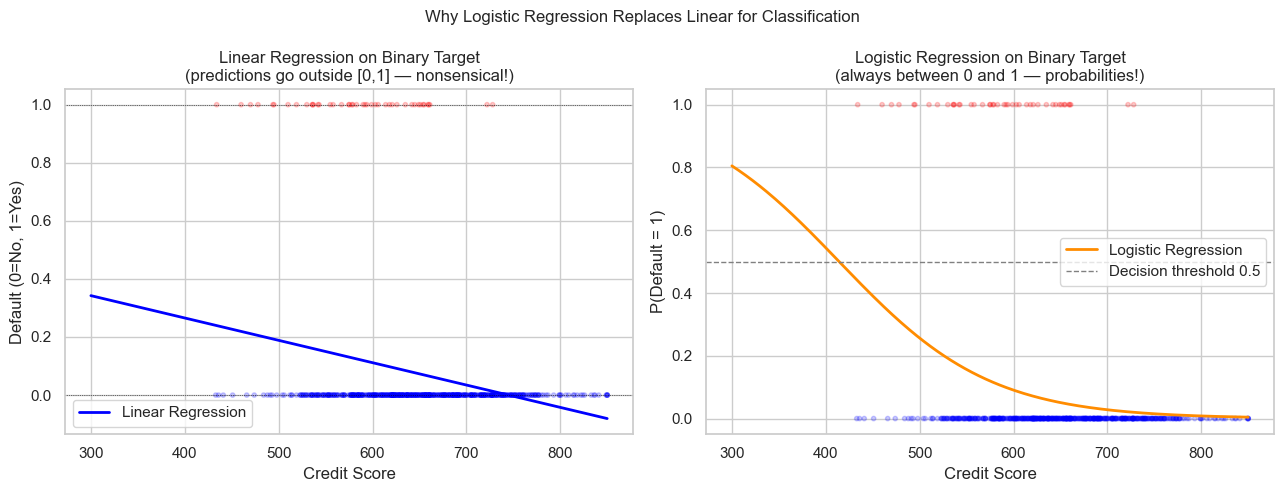

In [55]:
# Demonstrate why linear regression fails for binary targets
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Linear regression fit
x_plot = df_loan['credit_score'].values.reshape(-1, 1)
y_plot = df_loan['default'].values

lr_fail = LinearRegression().fit(x_plot, y_plot)
x_range = np.linspace(300, 850, 300).reshape(-1, 1)
y_lr    = lr_fail.predict(x_range)

axes[0].scatter(df_loan['credit_score'], df_loan['default'],
                alpha=0.2, c=df_loan['default'], cmap='bwr', s=10)
axes[0].plot(x_range, y_lr, color='blue', lw=2, label='Linear Regression')
axes[0].axhline(0, color='black', lw=0.5, ls=':')
axes[0].axhline(1, color='black', lw=0.5, ls=':')
axes[0].set_xlabel('Credit Score')
axes[0].set_ylabel('Default (0=No, 1=Yes)')
axes[0].set_title('Linear Regression on Binary Target\n(predictions go outside [0,1] — nonsensical!)')
axes[0].legend()

# Logistic regression fit
logr_demo = LogisticRegression()
logr_demo.fit(x_plot, y_plot)
y_logr = logr_demo.predict_proba(x_range)[:, 1]

axes[1].scatter(df_loan['credit_score'], df_loan['default'],
                alpha=0.2, c=df_loan['default'], cmap='bwr', s=10)
axes[1].plot(x_range, y_logr, color='darkorange', lw=2, label='Logistic Regression')
axes[1].axhline(0.5, color='gray', lw=1, ls='--', label='Decision threshold 0.5')
axes[1].set_xlabel('Credit Score')
axes[1].set_ylabel('P(Default = 1)')
axes[1].set_title('Logistic Regression on Binary Target\n(always between 0 and 1 — probabilities!)')
axes[1].legend()

plt.suptitle('Why Logistic Regression Replaces Linear for Classification', fontsize=12)
plt.tight_layout()
plt.show()

---
## 7. The Sigmoid Function

Logistic regression applies the **sigmoid function** to a linear combination of features:

$$\hat{p} = \sigma(z) = \frac{1}{1 + e^{-z}} \qquad \text{where} \qquad z = w_1 x_1 + \ldots + w_p x_p + b$$

The sigmoid function:
- Maps any real number to the range (0, 1)
- Outputs the **probability** of belonging to class 1
- At $z = 0$: $\sigma(0) = 0.5$ — equal probability of either class
- As $z \to +\infty$: $\sigma(z) \to 1$
- As $z \to -\infty$: $\sigma(z) \to 0$

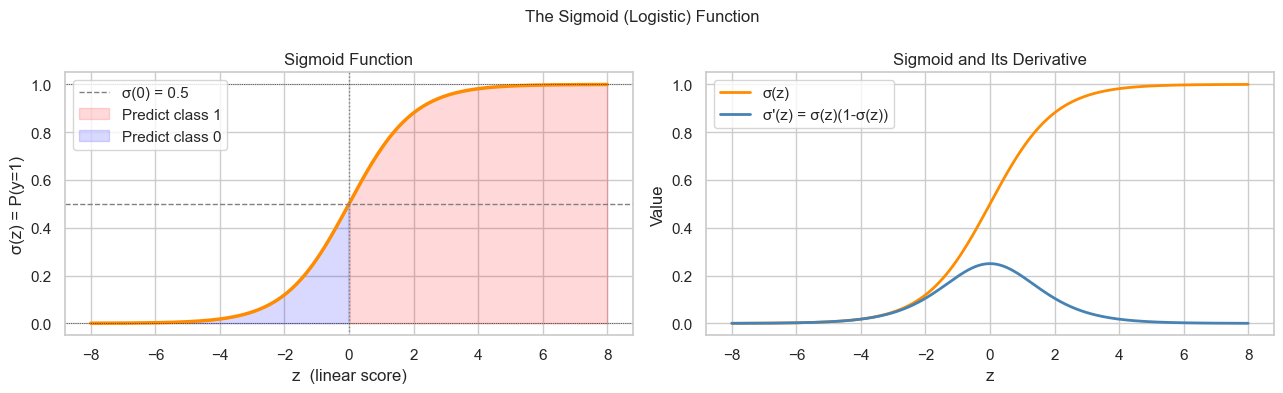

Key properties:
  σ(-8) = 0.000335  (very confident: class 0)
  σ( 0) = 0.500000  (uncertain: 50/50)
  σ(+8) = 0.999665  (very confident: class 1)

The decision boundary is z = 0, which corresponds to σ(z) = 0.5


In [56]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-8, 8, 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Sigmoid curve
axes[0].plot(z, sigmoid(z), color='darkorange', lw=2.5)
axes[0].axhline(0.5, color='gray',  lw=1, ls='--', label='σ(0) = 0.5')
axes[0].axvline(0.0, color='gray',  lw=1, ls=':')
axes[0].axhline(1.0, color='black', lw=0.5, ls=':')
axes[0].axhline(0.0, color='black', lw=0.5, ls=':')
axes[0].fill_between(z, 0, sigmoid(z), where=(z >= 0), alpha=0.15, color='red',  label='Predict class 1')
axes[0].fill_between(z, 0, sigmoid(z), where=(z <  0), alpha=0.15, color='blue', label='Predict class 0')
axes[0].set_xlabel('z  (linear score)')
axes[0].set_ylabel('σ(z) = P(y=1)')
axes[0].set_title('Sigmoid Function')
axes[0].legend()

# Derivative of sigmoid (used in backpropagation)
dsigmoid = sigmoid(z) * (1 - sigmoid(z))
axes[1].plot(z, sigmoid(z),  color='darkorange', lw=2, label="σ(z)")
axes[1].plot(z, dsigmoid,    color='steelblue',  lw=2, label="σ'(z) = σ(z)(1-σ(z))")
axes[1].set_xlabel('z')
axes[1].set_ylabel('Value')
axes[1].set_title('Sigmoid and Its Derivative')
axes[1].legend()

plt.suptitle('The Sigmoid (Logistic) Function', fontsize=12)
plt.tight_layout()
plt.show()

print('Key properties:')
print(f'  σ(-8) = {sigmoid(-8):.6f}  (very confident: class 0)')
print(f'  σ( 0) = {sigmoid(0):.6f}  (uncertain: 50/50)')
print(f'  σ(+8) = {sigmoid(8):.6f}  (very confident: class 1)')
print()
print('The decision boundary is z = 0, which corresponds to σ(z) = 0.5')

---
## 8. Binary Cross-Entropy Loss

For binary classification, MSE is not ideal. We use **Binary Cross-Entropy** (also called Log Loss):

$$J(\mathbf{w}) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{p}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{p}^{(i)}) \right]$$

- When $y = 1$: loss = $-\log(\hat{p})$ — penalises predicting low probability for a true positive
- When $y = 0$: loss = $-\log(1 - \hat{p})$ — penalises predicting high probability for a true negative
- A perfect prediction ($\hat{p} = 1$ when $y = 1$) gives $\log(1) = 0$ loss

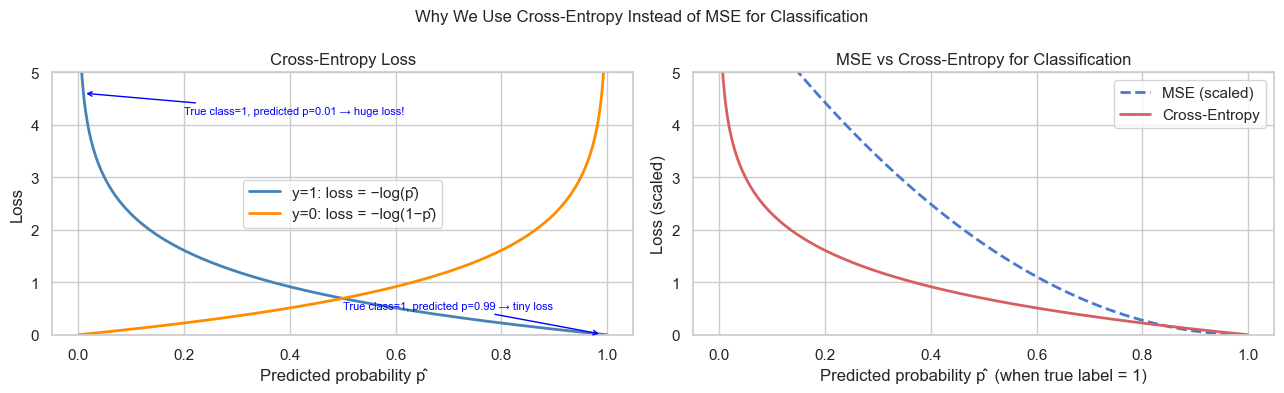

Cross-Entropy penalises VERY wrong predictions much more heavily than MSE.
This is desirable: being very confident and very wrong should be punished severely.


In [57]:
p = np.linspace(0.001, 0.999, 300)

loss_y1 = -np.log(p)         # loss when true label = 1
loss_y0 = -np.log(1 - p)     # loss when true label = 0

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(p, loss_y1, color='steelblue',   lw=2, label='y=1: loss = −log(p̂)')
axes[0].plot(p, loss_y0, color='darkorange',  lw=2, label='y=0: loss = −log(1−p̂)')
axes[0].set_ylim(0, 5)
axes[0].set_xlabel('Predicted probability p̂')
axes[0].set_ylabel('Loss')
axes[0].set_title('Cross-Entropy Loss')
axes[0].legend()

# Annotate specific cases
axes[0].annotate('True class=1, predicted p=0.01 → huge loss!',
                 xy=(0.01, -np.log(0.01)), xytext=(0.2, 4.2),
                 arrowprops=dict(arrowstyle='->', color='blue'), color='blue', fontsize=8)

axes[0].annotate('True class=1, predicted p=0.99 → tiny loss',
                 xy=(0.99, -np.log(0.99)), xytext=(0.5, 0.5),
                 arrowprops=dict(arrowstyle='->', color='blue'), color='blue', fontsize=8)

# Comparison: MSE vs Log-Loss for binary
p_vals = np.linspace(0.001, 0.999, 300)
mse_y1  = (1 - p_vals) ** 2
bce_y1  = -np.log(p_vals)

axes[1].plot(p_vals, mse_y1 / mse_y1.max() * bce_y1.max(), 'b--', lw=2, label='MSE (scaled)')
axes[1].plot(p_vals, bce_y1, 'r-', lw=2, label='Cross-Entropy')
axes[1].set_ylim(0, 5)
axes[1].set_xlabel('Predicted probability p̂  (when true label = 1)')
axes[1].set_ylabel('Loss (scaled)')
axes[1].set_title('MSE vs Cross-Entropy for Classification')
axes[1].legend()

plt.suptitle('Why We Use Cross-Entropy Instead of MSE for Classification', fontsize=12)
plt.tight_layout()
plt.show()

print('Cross-Entropy penalises VERY wrong predictions much more heavily than MSE.')
print('This is desirable: being very confident and very wrong should be punished severely.')

---
## 9. Logistic Regression with sklearn

In [58]:
loan_features = ['credit_score', 'income_k', 'loan_to_income', 'employment_yrs', 'num_open_acc']

X_loan = df_loan[loan_features]
y_loan = df_loan['default']

Xl_tr, Xl_te, yl_tr, yl_te = train_test_split(
    X_loan, y_loan, test_size=0.25, random_state=42, stratify=y_loan
)

# Pipeline: scale + logistic regression
logr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logr',   LogisticRegression(C=1.0, random_state=42)),  # C = 1/alpha
])

logr_pipe.fit(Xl_tr, yl_tr)

y_pred_class = logr_pipe.predict(Xl_te)
y_pred_prob  = logr_pipe.predict_proba(Xl_te)[:, 1]

# Show learned coefficients
logr_model  = logr_pipe.named_steps['logr']
coeff_table = pd.DataFrame({
    'feature': loan_features,
    'coeff':   logr_model.coef_[0]
}).sort_values('coeff', key=abs, ascending=False)

print('Logistic Regression Coefficients (log-odds scale):')
print()
print(f"  {'Feature':>16}   {'Coeff (log-odds)':>18}   {'Odds Ratio':>12}   {'Effect'}")
print('  ' + '─' * 65)
for _, row in coeff_table.iterrows():
    effect = 'increases default risk' if row['coeff'] > 0 else 'decreases default risk'
    odds_r = np.exp(row['coeff'])
    print(f"  {row['feature']:>16}   {row['coeff']:>18.4f}   {odds_r:>12.4f}   {effect}")

print()
print('Odds ratio > 1 → increases odds of default per 1-std increase in feature')
print('Odds ratio < 1 → decreases odds of default per 1-std increase in feature')

Logistic Regression Coefficients (log-odds scale):

           Feature     Coeff (log-odds)     Odds Ratio   Effect
  ─────────────────────────────────────────────────────────────────
    loan_to_income               1.5188         4.5667   increases default risk
      credit_score              -1.4330         0.2386   decreases default risk
          income_k              -1.1592         0.3137   decreases default risk
      num_open_acc               0.9037         2.4688   increases default risk
    employment_yrs              -0.8895         0.4109   decreases default risk

Odds ratio > 1 → increases odds of default per 1-std increase in feature
Odds ratio < 1 → decreases odds of default per 1-std increase in feature


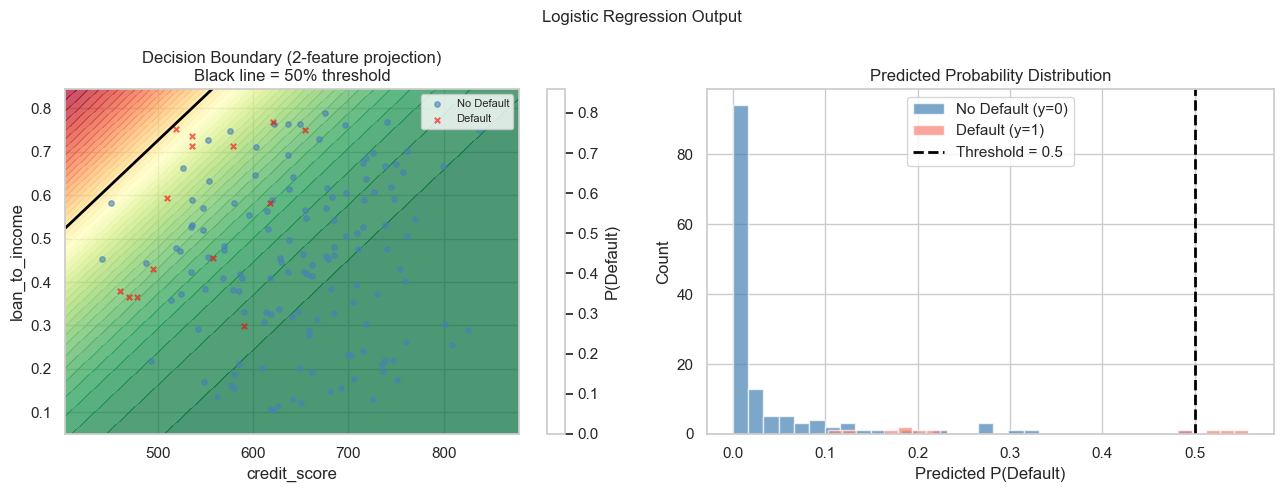

In [59]:
# Visualise the decision boundary (2-feature projection)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 2D slice: credit_score vs loan_to_income
feat1, feat2 = 'credit_score', 'loan_to_income'

X2 = df_loan[[feat1, feat2]].values
y2 = df_loan['default'].values

X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2, y2, test_size=0.25, random_state=42)

pipe2 = Pipeline([('sc', StandardScaler()), ('lr', LogisticRegression(C=1.0))])
pipe2.fit(X2_tr, y2_tr)

# Create mesh grid for the decision surface
h = 2
xx, yy = np.meshgrid(
    np.arange(X2[:, 0].min() - 30, X2[:, 0].max() + 30, h),
    np.arange(X2[:, 1].min() - 0.05, X2[:, 1].max() + 0.05, 0.005)
)
Z = pipe2.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

axes[0].contourf(xx, yy, Z, levels=50, cmap='RdYlGn_r', alpha=0.7)
plt.colorbar(axes[0].contourf(xx, yy, Z, levels=50, cmap='RdYlGn_r', alpha=0), ax=axes[0], label='P(Default)')
axes[0].contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
axes[0].scatter(X2_te[y2_te == 0, 0], X2_te[y2_te == 0, 1],
                color='steelblue', alpha=0.6, s=15, label='No Default')
axes[0].scatter(X2_te[y2_te == 1, 0], X2_te[y2_te == 1, 1],
                color='red',       alpha=0.6, s=15, marker='x', label='Default')
axes[0].set_xlabel(feat1)
axes[0].set_ylabel(feat2)
axes[0].set_title('Decision Boundary (2-feature projection)\nBlack line = 50% threshold')
axes[0].legend(fontsize=8)

# Predicted probability histogram
axes[1].hist(y_pred_prob[yl_te == 0], bins=30, alpha=0.7, color='steelblue', label='No Default (y=0)')
axes[1].hist(y_pred_prob[yl_te == 1], bins=30, alpha=0.7, color='salmon',    label='Default (y=1)')
axes[1].axvline(0.5, color='black', lw=2, ls='--', label='Threshold = 0.5')
axes[1].set_xlabel('Predicted P(Default)')
axes[1].set_ylabel('Count')
axes[1].set_title('Predicted Probability Distribution')
axes[1].legend()

plt.suptitle('Logistic Regression Output', fontsize=12)
plt.tight_layout()
plt.show()

---
## 10. Evaluation: Confusion Matrix, Precision, Recall, F1

**Accuracy alone is misleading** for imbalanced classes.  
If 95% of loans don't default, a model that predicts "no default" always achieves 95% accuracy — but is useless.

### Confusion Matrix

```
                    Predicted
               No Default | Default
Actual No Def |    TN      |  FP    |  ← Predicted default when actually not
       Default |    FN      |  TP    |  ← Predicted no default when actually defaulted
```

| Metric | Formula | Answers |
|---|---|---|
| **Accuracy** | (TP+TN) / Total | What fraction did we predict correctly? |
| **Precision** | TP / (TP+FP) | Of all predicted defaults, how many actually defaulted? |
| **Recall (Sensitivity)** | TP / (TP+FN) | Of all actual defaults, how many did we catch? |
| **F1 Score** | 2 × (P × R) / (P + R) | Harmonic mean — balance between Precision and Recall |

> **Business context matters:** A bank cares more about **Recall** (missing a default is very costly) than Precision (flagging a good borrower as risky is annoying but manageable).

In [60]:
# Compute all metrics
acc   = accuracy_score(yl_te, y_pred_class)
prec  = precision_score(yl_te, y_pred_class)
rec   = recall_score(yl_te, y_pred_class)
f1    = f1_score(yl_te, y_pred_class)
cm    = confusion_matrix(yl_te, y_pred_class)

tn, fp, fn, tp = cm.ravel()

print('Classification Report:')
print(classification_report(yl_te, y_pred_class, target_names=['No Default', 'Default']))

Classification Report:
              precision    recall  f1-score   support

  No Default       0.95      1.00      0.97       139
     Default       1.00      0.27      0.43        11

    accuracy                           0.95       150
   macro avg       0.97      0.64      0.70       150
weighted avg       0.95      0.95      0.93       150



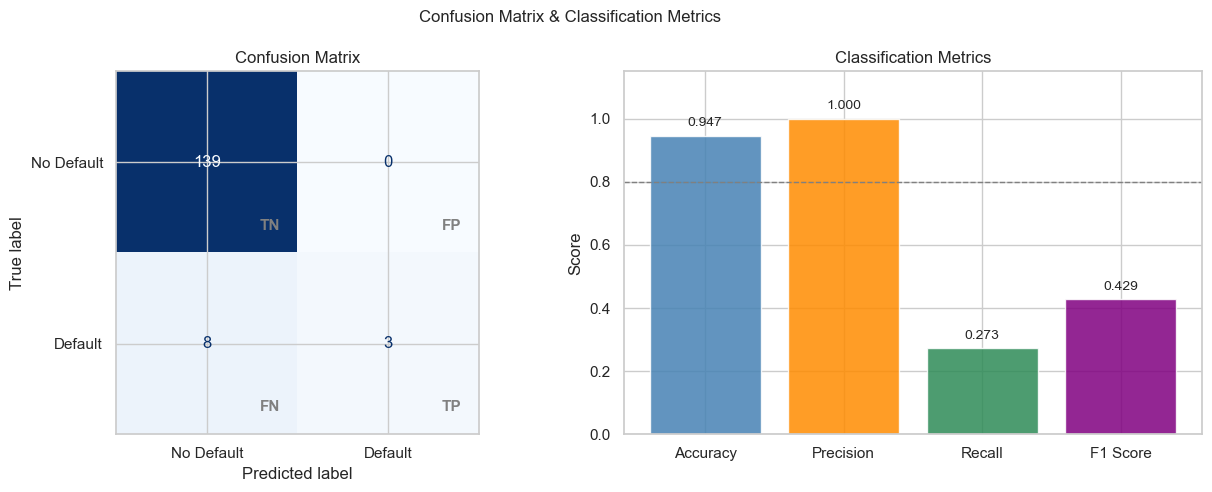

TN (correctly predicted no default):  139
FP (false alarm — flagged as default): 0
FN (missed default — most dangerous!): 8
TP (correctly predicted default):      3

Bank perspective: FN cost > FP cost → we want high Recall (currently 0.273)


In [61]:
# Annotated confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix heatmap
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default', 'Default'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix')

# Annotate TN/FP/FN/TP
for i, (row_lbl, col_lbl) in enumerate([(0, 'TN'), (1, 'FP'), (2, 'FN'), (3, 'TP')]):
    r, c = divmod(i, 2)
    axes[0].text(c + 0.35, r + 0.35, col_lbl, ha='center', va='center',
                 fontsize=11, color='gray', fontweight='bold')

# Metrics bar chart
metrics = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1 Score': f1}
bar_colours = ['steelblue', 'darkorange', 'seagreen', 'purple']

bars = axes[1].bar(list(metrics.keys()), list(metrics.values()),
                   color=bar_colours, alpha=0.85, edgecolor='white')
axes[1].set_ylim(0, 1.15)
axes[1].axhline(0.8, color='gray', ls='--', lw=1)
axes[1].set_ylabel('Score')
axes[1].set_title('Classification Metrics')

for bar, val in zip(bars, metrics.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Confusion Matrix & Classification Metrics', fontsize=12)
plt.tight_layout()
plt.show()

print(f'TN (correctly predicted no default):  {tn}')
print(f'FP (false alarm — flagged as default): {fp}')
print(f'FN (missed default — most dangerous!): {fn}')
print(f'TP (correctly predicted default):      {tp}')
print()
print(f'Bank perspective: FN cost > FP cost → we want high Recall (currently {rec:.3f})')

---
## 11. ROC Curve & AUC

The **Receiver Operating Characteristic (ROC)** curve shows the trade-off between:
- **True Positive Rate (Recall)** = TP / (TP + FN)  — catching real defaults
- **False Positive Rate** = FP / (FP + TN)          — incorrectly flagging good borrowers

at every possible threshold.

**AUC (Area Under the Curve):**
- AUC = 1.0: perfect model
- AUC = 0.5: random guessing (diagonal line)
- AUC = 0.0: perfectly wrong

> AUC measures a model's ability to **rank** positives above negatives, regardless of threshold.

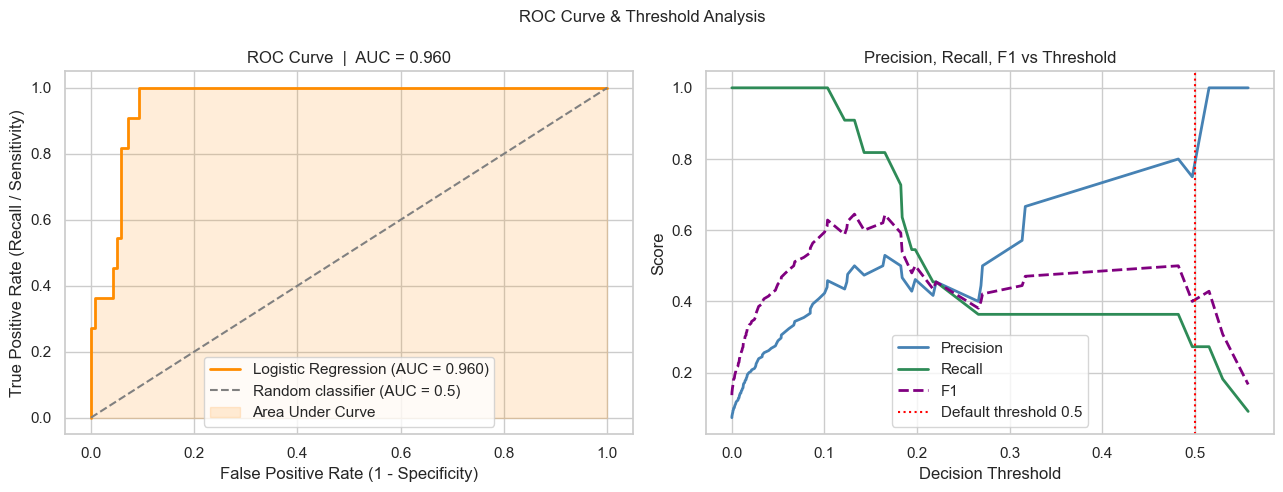

AUC = 0.960

AUC interpretation: if you randomly pick one defaulter and one non-defaulter,
the model ranks the defaulter higher 96.0% of the time.


In [62]:
fpr, tpr, thresholds = roc_curve(yl_te, y_pred_prob)
auc = roc_auc_score(yl_te, y_pred_prob)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curve
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'Logistic Regression (AUC = {auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='gray', lw=1.5, ls='--', label='Random classifier (AUC = 0.5)')
axes[0].fill_between(fpr, tpr, alpha=0.15, color='darkorange', label='Area Under Curve')
axes[0].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0].set_ylabel('True Positive Rate (Recall / Sensitivity)')
axes[0].set_title(f'ROC Curve  |  AUC = {auc:.3f}')
axes[0].legend()

# Threshold vs precision/recall
from sklearn.metrics import precision_recall_curve
prec_c, rec_c, thresh_c = precision_recall_curve(yl_te, y_pred_prob)

axes[1].plot(thresh_c, prec_c[:-1], color='steelblue',  lw=2, label='Precision')
axes[1].plot(thresh_c, rec_c[:-1],  color='seagreen',   lw=2, label='Recall')

# F1 at each threshold
f1_scores = 2 * prec_c[:-1] * rec_c[:-1] / (prec_c[:-1] + rec_c[:-1] + 1e-9)
axes[1].plot(thresh_c, f1_scores, color='purple', lw=2, ls='--', label='F1')

axes[1].axvline(0.5, color='red', ls=':', lw=1.5, label='Default threshold 0.5')
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision, Recall, F1 vs Threshold')
axes[1].legend()

plt.suptitle('ROC Curve & Threshold Analysis', fontsize=12)
plt.tight_layout()
plt.show()

print(f'AUC = {auc:.3f}')
print()
print('AUC interpretation: if you randomly pick one defaulter and one non-defaulter,')
print(f'the model ranks the defaulter higher {auc*100:.1f}% of the time.')

---
## 12. Decision Threshold Tuning

The default threshold is 0.5 (predict class 1 when $\hat{p} \geq 0.5$). But this is not always optimal.

**Bank context:**
- A missed default (FN) costs the bank $50,000 in lost principal
- A false alarm (FP) costs $500 in processing fees

Lowering the threshold (e.g., to 0.3) catches more defaults (higher Recall) at the cost of more false alarms.

In [63]:
# Compare metrics at different thresholds
threshold_grid = [0.3, 0.4, 0.5, 0.6, 0.7]

FN_COST = 50_000
FP_COST = 500

print(f"{'Threshold':>10}   {'Precision':>10}   {'Recall':>8}   {'F1':>8}   {'FN':>6}   {'FP':>6}   {'Total Cost':>14}")
print('─' * 75)

best_cost  = float('inf')
best_thresh = 0.5

for thresh in threshold_grid:
    y_pred_t = (y_pred_prob >= thresh).astype(int)
    cm_t     = confusion_matrix(yl_te, y_pred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()

    prec_t = precision_score(yl_te, y_pred_t, zero_division=0)
    rec_t  = recall_score(yl_te, y_pred_t, zero_division=0)
    f1_t   = f1_score(yl_te, y_pred_t, zero_division=0)
    cost   = fn_t * FN_COST + fp_t * FP_COST

    flag = ' ← default' if thresh == 0.5 else ''
    if cost < best_cost:
        best_cost   = cost
        best_thresh = thresh
        flag        = ' ← optimal'

    print(f"{thresh:>10.1f}   {prec_t:>10.3f}   {rec_t:>8.3f}   {f1_t:>8.3f}   "
          f"{fn_t:>6}   {fp_t:>6}   ${cost:>13,.0f}{flag}")

print()
print(f'Optimal threshold for minimising cost: {best_thresh}')
print(f'Assumption: FN costs ${FN_COST:,}  |  FP costs ${FP_COST:,}')
print()
print('Lesson: the best threshold depends on the BUSINESS COST of each error type, not just F1.')

 Threshold    Precision     Recall         F1       FN       FP       Total Cost
───────────────────────────────────────────────────────────────────────────
       0.3        0.571      0.364      0.444        7        3   $      351,500 ← optimal
       0.4        0.800      0.364      0.500        7        1   $      350,500 ← optimal
       0.5        1.000      0.273      0.429        8        0   $      400,000 ← default
       0.6        0.000      0.000      0.000       11        0   $      550,000
       0.7        0.000      0.000      0.000       11        0   $      550,000

Optimal threshold for minimising cost: 0.4
Assumption: FN costs $50,000  |  FP costs $500

Lesson: the best threshold depends on the BUSINESS COST of each error type, not just F1.


---
## 13. Multiclass Logistic Regression

Logistic Regression extends to more than two classes:

| Strategy | How | When |
|---|---|---|
| **One-vs-Rest (OvR)** | Train $K$ binary classifiers (one per class vs all others) | Simple, works for any binary base classifier |
| **Multinomial (Softmax)** | Single model with softmax output — outputs a probability for each class | Better probability calibration |

** With new versions, the best strategy is selected by the library itself

In [76]:
# Multiclass: 3-class credit rating (Good / Marginal / Poor)
N_mc = 450

cs   = np.random.normal(650, 100, N_mc).clip(300, 850)
debt = np.random.normal(0.35, 0.12, N_mc).clip(0, 1)
inc  = np.random.lognormal(4.0, 0.5, N_mc)
emp  = np.random.exponential(5, N_mc).clip(0, 30)

# Credit rating based on features
score = 0.5 * (cs - 300) / 550  - 0.4 * debt + 0.1 * (inc - 30) / 270 + 0.2 * emp / 30
score += np.random.normal(0, 0.1, N_mc)

credit_rating = pd.cut(score, bins=[-float('inf'), 0.25, 0.55, float('inf')],
                       labels=['Poor', 'Marginal', 'Good'])

X_mc = pd.DataFrame({'credit_score': cs, 'debt_ratio': debt, 'income': inc, 'employment': emp})
print(X_mc.head())
y_mc = np.array(credit_rating)  # one label per sample: 'Poor', 'Marginal', or 'Good'
print(f'Multiclass dataset: {X_mc.shape}, Classes: {np.unique(y_mc)}')
X_mc_tr, X_mc_te, y_mc_tr, y_mc_te = train_test_split(
    X_mc.values, y_mc, test_size=0.25, random_state=42
)
print(f'Train set: {X_mc_tr.shape}, Test set: {X_mc_te.shape}')
#print test y size
print(f'Test labels distribution:')
print(pd.Series(y_mc_te).value_counts())

pipe_mc = Pipeline([
        ('sc', StandardScaler()),
        ('lr', LogisticRegression(max_iter=500, random_state=42)),
])
pipe_mc.fit(X_mc_tr, y_mc_tr)
acc_mc = accuracy_score(y_mc_te, pipe_mc.predict(X_mc_te))
print(f'Accuracy = {acc_mc:.3f}')

print()
print('Classification report (Multinomial):')
pipe_softmax = Pipeline([('sc', StandardScaler()),
                         ('lr', LogisticRegression(max_iter=500))])
pipe_softmax.fit(X_mc_tr, y_mc_tr)
print(classification_report(y_mc_te, pipe_softmax.predict(X_mc_te),
                             target_names=['Good', 'Marginal', 'Poor']))

   credit_score  debt_ratio     income  employment
0    650.634531    0.407068  91.064333    0.453340
1    807.622428    0.311700  49.330605    6.334663
2    717.540133    0.411911  86.084914    1.537260
3    748.067200    0.234207  15.820844    0.613878
4    683.973352    0.397313  95.174588    9.474483
Multiclass dataset: (450, 4), Classes: ['Good' 'Marginal' 'Poor']
Train set: (337, 4), Test set: (113, 4)
Test labels distribution:
Poor        59
Marginal    52
Good         2
Name: count, dtype: int64
Accuracy = 0.717

Classification report (Multinomial):
              precision    recall  f1-score   support

        Good       0.00      0.00      0.00         2
    Marginal       0.79      0.52      0.63        52
        Poor       0.69      0.92      0.79        59

    accuracy                           0.72       113
   macro avg       0.50      0.48      0.47       113
weighted avg       0.73      0.72      0.70       113



---
## 14. Summary

### Part A — Regularisation

| Method | Penalty | Coefficients at 0? | Best when |
|---|---|---|---|
| **OLS** | None | No | Features are all relevant, no noise |
| **Ridge (L2)** | $\alpha \sum w_j^2$ | No — shrinks but not zero | Many features, all contribute a little |
| **Lasso (L1)** | $\alpha \sum |w_j|$ | **Yes** — exact feature selection | Many features, most are irrelevant |
| **ElasticNet** | Combination | Yes | Correlated features + some irrelevant ones |

**Rule of thumb:**
- When in doubt, try Lasso first — it does feature selection for you
- If features are correlated, use ElasticNet
- Always tune $\alpha$ via cross-validation, not by guessing

### Part B — Logistic Regression

| Concept | Key takeaway |
|---|---|
| **Sigmoid** | Converts linear score to probability (0,1) |
| **Cross-entropy** | The right loss for binary classification — heavily penalises confident wrong predictions |
| **Decision boundary** | Where P(class 1) = threshold (usually 0.5) |
| **Confusion matrix** | Shows TP, TN, FP, FN — the building blocks of all classification metrics |
| **Precision** | Of all positive predictions, how many are real? |
| **Recall** | Of all real positives, how many did we catch? |
| **F1** | Harmonic mean — use when you want balance between P and R |
| **AUC** | Model's ability to rank positives above negatives — threshold-independent |
| **Threshold tuning** | Move the threshold based on business cost of FP vs FN |

---

**What comes next:** Decision Trees, Random Forests, and Gradient Boosting — powerful non-linear models that do not require feature scaling or explicit feature engineering.

In [77]:
# Final summary: all regularisation results
print('=' * 65)
print('FINAL COMPARISON: OLS vs Regularised Models')
print('=' * 65)
print()

final_models = [
    ('OLS (no reg.)',      LinearRegression()),
    ('Ridge (CV-tuned)',   Ridge(alpha=ridgecv.alpha_)),
    ('Lasso (CV-tuned)',   Lasso(alpha=lassocv.alpha_, max_iter=10_000)),
]

print(f"  {'Model':>20}   {'Test RMSE':>12}   {'Test R²':>10}   {'Non-zero coeff':>15}")
print('  ' + '─' * 65)

for name, mdl in final_models:
    mdl.fit(X_train_s, y_train)
    te_pred = mdl.predict(X_test_s)
    rmse = np.sqrt(mean_squared_error(y_test, te_pred))
    r2   = r2_score(y_test, te_pred)
    nz   = np.sum(mdl.coef_ != 0)
    print(f"  {name:>20}   ${rmse:>10,.0f}   {r2:>10.4f}   {nz:>15}")

print()
print('Key lesson:')
print('  OLS assigns coefficients to all 20 features including the 15 noise features.')
print('  Lasso eliminates most noise features → better generalisation, simpler model.')
print('  Ridge shrinks all coefficients → reduces overfitting without eliminating features.')

FINAL COMPARISON: OLS vs Regularised Models

                 Model      Test RMSE      Test R²    Non-zero coeff
  ─────────────────────────────────────────────────────────────────
         OLS (no reg.)   $    23,568       0.9342                20
      Ridge (CV-tuned)   $    23,564       0.9342                20
      Lasso (CV-tuned)   $    22,627       0.9393                14

Key lesson:
  OLS assigns coefficients to all 20 features including the 15 noise features.
  Lasso eliminates most noise features → better generalisation, simpler model.
  Ridge shrinks all coefficients → reduces overfitting without eliminating features.
